In [1]:
#TASK 1: DATA  UNDERSTANDING

#Import tools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load dataset into pyhton

df = pd.read_csv('OnlineRetail.csv', encoding='ISO-8859-1')
print("Dataset loaded successfully")

Dataset loaded successfully


In [3]:
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom


In [4]:
#Check the Size of the Dataset

print("Number of rows and columns:", df.shape)
print("Total rows:", df.shape[0])
print("Total columns:", df.shape[1])

Number of rows and columns: (541909, 8)
Total rows: 541909
Total columns: 8


In [5]:
#Check Data Types

print("Data types of each column:")
print(df.dtypes)

Data types of each column:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [6]:
#Select only numerical columns(int64 and float64)

numerical_cols = df.select_dtypes(include='number').columns.tolist()
print("Numericals columns:", numerical_cols)

#Select only categorical columns (object = text)

categorical_cols = df.select_dtypes(include = 'object').columns.tolist()
print("Categorical columns:", categorical_cols)

Numericals columns: ['Quantity', 'UnitPrice', 'CustomerID']
Categorical columns: ['InvoiceNo', 'StockCode', 'Description', 'InvoiceDate', 'Country']


In [7]:
#Find Unique Identifiers

print("unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

unique values per column:
InvoiceNo: 25900 unique values
StockCode: 4070 unique values
Description: 4223 unique values
Quantity: 722 unique values
InvoiceDate: 23260 unique values
UnitPrice: 1630 unique values
CustomerID: 4372 unique values
Country: 38 unique values


In [8]:
#Brief Dataset Description

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [9]:
#TASK 2: DATA CLEANING

#Checking missing values

missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum()/len(df) *100).round (2)
missing_table = pd.DataFrame({'Missing Values': missing_count,'Percentage(%)' : missing_percent})
print ("Missing Values Report:")
print(missing_table)


Missing Values Report:
             Missing Values  Percentage(%)
InvoiceNo                 0           0.00
StockCode                 0           0.00
Description            1454           0.27
Quantity                  0           0.00
InvoiceDate               0           0.00
UnitPrice                 0           0.00
CustomerID           135080          24.93
Country                   0           0.00


In [10]:
#Handle Missing Values
#-- Handle Description--

before_rows = len(df) 
df.dropna(subset=['Description'], inplace= True)
after_rows = len(df)
print(f"Rows before: {before_rows}")
print(f"Row after:{after_rows}")
print(f"Rows removed: {before_rows - after_rows}")


Rows before: 541909
Row after:540455
Rows removed: 1454


In [11]:
#-- Handle CustomerID --

df['CustomerID_missing'] = df['CustomerID'].isnull()
print(f"\nRows flagged as missing CustomerID: {df['CustomerID_missing'].sum()}")


Rows flagged as missing CustomerID: 133626


In [12]:
#Find and Remove Duplicate
#-- Find Duplicate --

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows found:{duplicates}")



Number of duplicate rows found:5268


In [13]:
#Remove Duplicate

df.drop_duplicates(keep='first', inplace = True)
print(f"Duplicates removed!")
print(f"Rows remaining:{len(df)}")


Duplicates removed!
Rows remaining:535187


In [14]:
#Standardization

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
print("Fix 1: InvoiceDate converted to datetime")
print("New type:", df['InvoiceDate'].dtype)





Fix 1: InvoiceDate converted to datetime
New type: datetime64[ns]


In [15]:
df['Description'] = df['Description'].str.strip().str.title()
print("Fix 2: Description text cleaned!")
df['Country'] =df['Country'].str.upper()
print("Fix 3: Country text cleaned!")

Fix 2: Description text cleaned!
Fix 3: Country text cleaned!


In [16]:
df.columns = df.columns.str.lower()
print("Fix 4: Columns names lowercased")
print("\nNew column names:", df.columns.tolist())


Fix 4: Columns names lowercased

New column names: ['invoiceno', 'stockcode', 'description', 'quantity', 'invoicedate', 'unitprice', 'customerid', 'country', 'customerid_missing']


In [17]:
#Data Validation
negative_qty = (df['quantity']<0).sum()
print(f"Rows with negative quantity (returns): {negative_qty}")



Rows with negative quantity (returns): 9725


In [18]:
zero_price = (df['unitprice']<=0).sum()
print(f"Rows with zero or negative unit price: {zero_price}")

Rows with zero or negative unit price: 1058


In [19]:
cancellations = df['invoiceno'].astype(str).str.startswith('C').sum()
print(f"Cancellation transactions (InvoiceNo starts with C): {cancellations}")

Cancellation transactions (InvoiceNo starts with C): 9251


In [20]:
#Create a Clean Dataset

is_cancellation = df['invoiceno'].astype(str).str.startswith('C')
df_clean = df [ (~is_cancellation) & (df['quantity']>0) & (df['unitprice']>0)
    ].copy()
print(f"Original df rows: {len(df)}")
print(f"Clean df rows: {len(df_clean)}")
print(f"Rows removed: {len(df) - len(df_clean)}")




Original df rows: 535187
Clean df rows: 524878
Rows removed: 10309


In [21]:
df_clean['totalsales'] = df_clean['quantity'] *df_clean['unitprice']
df_clean['year'] = df_clean['invoicedate'].dt.year
df_clean['month'] = df_clean['invoicedate'].dt.month
df_clean['month_name'] = df_clean['invoicedate'].dt.strftime('%b')
df_clean['year_month'] = df_clean['invoicedate'].dt.to_period('M')
print("New columns added successfully!")
print(df_clean[['quantity','unitprice','totalsales','year','month','month_name','year_month']].head())





New columns added successfully!
   quantity  unitprice  totalsales  year  month month_name year_month
0         6       2.55       15.30  2010     12        Dec    2010-12
1         6       3.39       20.34  2010     12        Dec    2010-12
2         8       2.75       22.00  2010     12        Dec    2010-12
3         6       3.39       20.34  2010     12        Dec    2010-12
4         6       3.39       20.34  2010     12        Dec    2010-12


In [22]:
#Cleaning Summary Table
summary = pd.DataFrame({'Issue Found':['Missing Description','Missing CustomerID','Duplicate Rows','Cancellation Transactions','Negative Quantities(Returns)',
                                       'Zero/Negative Unit Price','InvoiceDate Format','Text Inconsistency','Column Names'],'Action Taken':['Dropped 1,454 rows(only 0.27%)',
                                       'Kept rows,flagged with CustomerID_missing column','Removed 5,268 duplicate rows','Excluded from df_clean(9,251 rows)','Excluded from df_clean(9725 rows)',
                                        'Excluded from df_clean(1,058 rows)', 'Converted from text to datetime','Description: Title Case, Country:UPPERCASE', 'ALL columns renamed to lowercase']})  
print(summary.to_string(index=False))
                                                                                                                                            


                 Issue Found                                     Action Taken
         Missing Description                   Dropped 1,454 rows(only 0.27%)
          Missing CustomerID Kept rows,flagged with CustomerID_missing column
              Duplicate Rows                     Removed 5,268 duplicate rows
   Cancellation Transactions               Excluded from df_clean(9,251 rows)
Negative Quantities(Returns)                Excluded from df_clean(9725 rows)
    Zero/Negative Unit Price               Excluded from df_clean(1,058 rows)
          InvoiceDate Format                  Converted from text to datetime
          Text Inconsistency       Description: Title Case, Country:UPPERCASE
                Column Names                 ALL columns renamed to lowercase


In [23]:
#TASK 3: EXPLORATORY DATA ANALYSIS (EDA)

df_clean[['quantity','unitprice','totalsales']].describe().round(2)

,quantity,unitprice,totalsales
count,524878.00,524878.00,524878.00
mean,10.62,3.92,20.28
std,156.28,36.09,271.69
min,1.00,0.00,0.00
25%,1.00,1.25,3.90
50%,4.00,2.08,9.92
75%,11.00,4.13,17.70
max,80995.00,13541.33,168469.60


In [24]:
#EDA 1: Top 10 Best-Selling Products by Quantity
top_products = (df_clean.groupby('description')['quantity'].sum().nlargest(10).reset_index())
top_products.columns = ['Product','Total Quantity Sold']
print("Top 10 Best-Selling Products:")
print(top_products.to_string(index=False))



Top 10 Best-Selling Products:
                           Product  Total Quantity Sold
       Paper Craft , Little Birdie                80995
    Medium Ceramic Top Storage Jar                78033
 World War 2 Gliders Asstd Designs                54951
           Jumbo Bag Red Retrospot                48371
White Hanging Heart T-Light Holder                37872
                    Popcorn Holder                36749
   Pack Of 72 Retrospot Cake Cases                36396
     Assorted Colour Bird Ornament                36362
                Rabbit Night Light                30739
            Mini Paint Set Vintage                26633


In [25]:
top_countries = (df_clean.groupby('country')['totalsales'].sum().nlargest(10).reset_index())
top_countries.columns = ['Country','Total Revenue(£)']
top_countries['Total Revenue(£)'] = top_countries['Total Revenue(£)'].round(2)
print("Top 10 Countries by Revenue:")
print(top_countries.to_string(index=False))

Top 10 Countries by Revenue:
       Country  Total Revenue(£)
UNITED KINGDOM        9001744.09
   NETHERLANDS         285446.34
          EIRE         283140.52
       GERMANY         228678.40
        FRANCE         209625.37
     AUSTRALIA         138453.81
         SPAIN          61558.56
   SWITZERLAND          57067.60
       BELGIUM          41196.34
        SWEDEN          38367.83


In [26]:
#EDA 3: Monthly Revenue Trend

monthly_sales=(df_clean.groupby('year_month')['totalsales'].sum().reset_index())
monthly_sales.columns= ['Year Month','Total Revenue']
monthly_sales['Total Revenue'] = monthly_sales['Total Revenue'].round(2)
monthly_sales['Year Month'] = monthly_sales['Year Month'].astype(str)
print("Monthly Revenue Trend:")
print(monthly_sales.to_string(index=False))

Monthly Revenue Trend:
Year Month  Total Revenue
   2010-12      821452.73
   2011-01      689811.61
   2011-02      522545.56
   2011-03      716215.26
   2011-04      536968.49
   2011-05      769296.61
   2011-06      760547.01
   2011-07      718076.12
   2011-08      757841.38
   2011-09     1056435.19
   2011-10     1151263.73
   2011-11     1503866.78
   2011-12      637790.33


In [27]:
#EDA 4: TOP 10 Customers by Revenue
top_customers = (df_clean.dropna(subset=['customerid']).groupby('customerid')['totalsales'].sum().nlargest(10).reset_index())
top_customers.columns = ['Customer ID','Total Spent']
top_customers['Total Spent']= top_customers['Total Spent'].round(2)
top_customers['Customer ID'] = top_customers ['Customer ID'].astype(int)
print("Top 10 Customers by Revenue:")
print(top_customers.to_string(index=False))




Top 10 Customers by Revenue:
 Customer ID  Total Spent
       14646    280206.02
       18102    259657.30
       17450    194390.79
       16446    168472.50
       14911    143711.17
       12415    124914.53
       14156    117210.08
       17511     91062.38
       16029     80850.84
       12346     77183.60


In [28]:
#EDA 5: How many orders does each customer make?
orders_per_customer = (df_clean.dropna(subset=['customerid']).groupby('customerid')['invoiceno'].nunique())
print(f"Customer Purchase Frequency:")
print(f"Average orders per customer: {orders_per_customer.mean():.1f}")
print(f"Median orders per customer: {orders_per_customer.median():0f}")
print(f"Most loyal customer (orders): {orders_per_customer.max()}")
print(f"One-time buyers: {(orders_per_customer == 1).sum()}")
print(f"Customers with 10+ orders:{(orders_per_customer >= 10).sum()}")

Customer Purchase Frequency:
Average orders per customer: 4.3
Median orders per customer: 2.000000
Most loyal customer (orders): 209
One-time buyers: 1493
Customers with 10+ orders:391


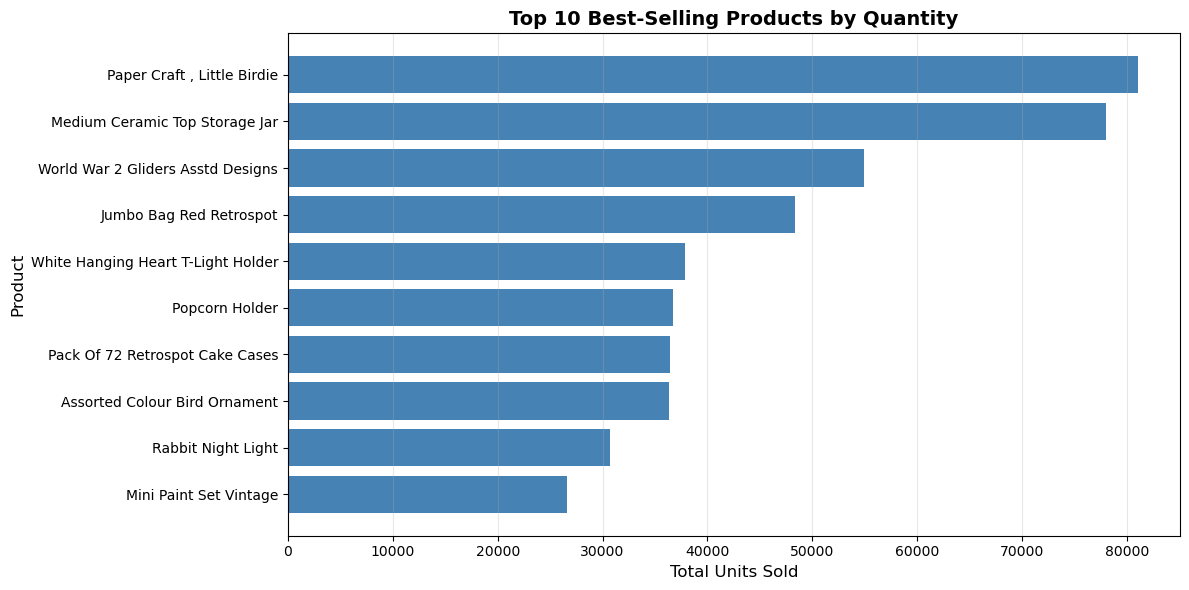

Chart 1 Findings: Paper Craft Little Birdie is the top seller
with 80,995 units - likely driven by one large bulk order.


In [29]:
#DATA VISUALIZATION
#Chart 1: Top 10 Best-Selling Products (Horizontal Bar Chart)

plt.figure(figsize=(12,6))
top_products_sorted=top_products.sort_values('Total Quantity Sold')
plt.barh(top_products_sorted['Product'],
         top_products_sorted['Total Quantity Sold'],
         color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity',
          fontsize=14,fontweight='bold')
plt.xlabel('Total Units Sold', fontsize=12)
plt.ylabel('Product', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print("Chart 1 Findings: Paper Craft Little Birdie is the top seller")
print("with 80,995 units - likely driven by one large bulk order.")

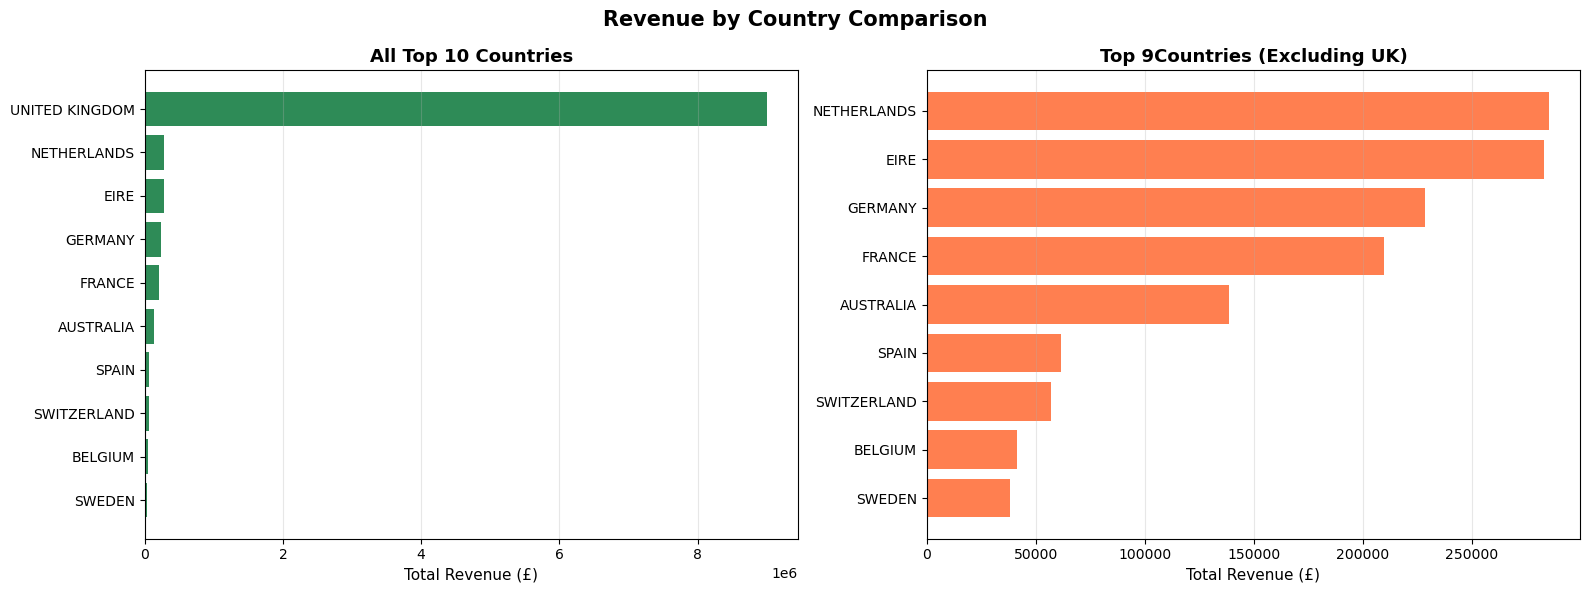

Chart 2 Findings: UK dominates with £9M. When excluded,
Netherlands, EIRE and Germany lead internaltional markets.


In [34]:
#Chart 2: Top 10 Revenue Generating Countries

top_countries = (df_clean.groupby('country')['totalsales']
                 .sum()
                 .nlargest(10)
                 .reset_index())
top_countries.columns = ['Country', 'Total Revenue']
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(16,6))
top_countries_sorted=top_countries.sort_values('Total Revenue')
ax1.barh(top_countries_sorted['Country'],
         top_countries_sorted['Total Revenue'],
         color='seagreen')
ax1.set_title('All Top 10 Countries',fontsize=13,fontweight='bold')
ax1.set_xlabel('Total Revenue (£)',fontsize=11)
ax1.grid(axis='x', alpha=0.3)
no_uk = top_countries[top_countries['Country'] !='UNITED KINGDOM']
no_uk_sorted = no_uk.sort_values('Total Revenue')
ax2.barh(no_uk_sorted['Country'],
         no_uk_sorted['Total Revenue'],
         color='coral')
ax2.set_title('Top 9Countries (Excluding UK)', fontsize=13,fontweight='bold')
ax2.set_xlabel('Total Revenue (£)', fontsize=11)
ax2.grid(axis='x',alpha=0.3)
plt.suptitle('Revenue by Country Comparison',fontsize=15,fontweight='bold')
plt.tight_layout()
plt.show()
print("Chart 2 Findings: UK dominates with £9M. When excluded,")
print("Netherlands, EIRE and Germany lead internaltional markets.")


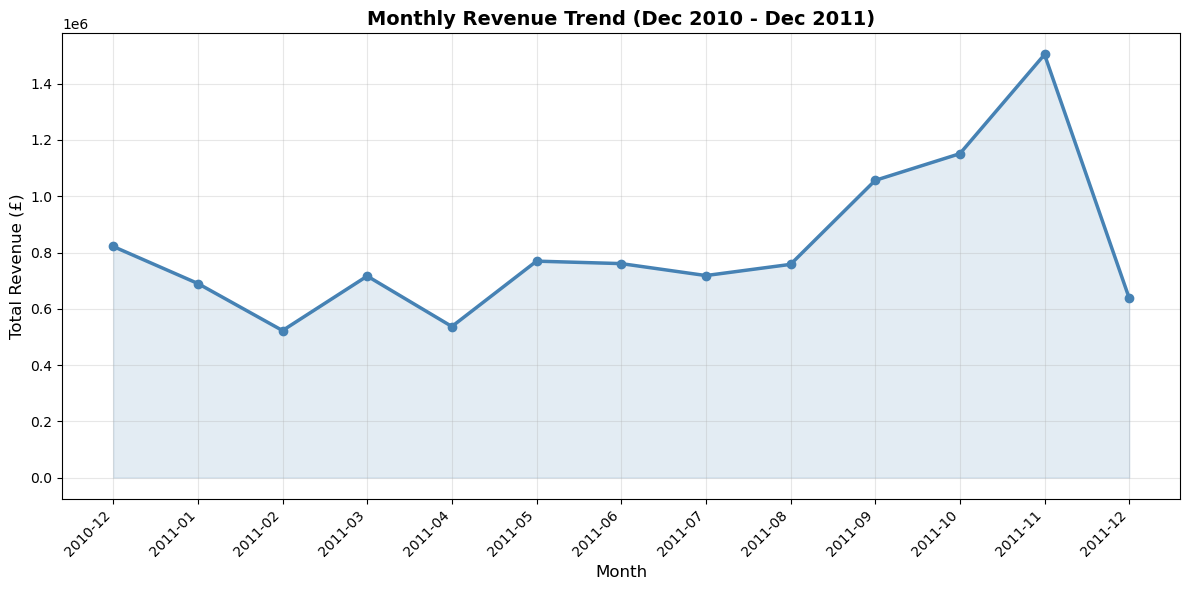

Chart 3 Finding: Revenue peaks in November 2011 at £1.5M,
showing strong seasonal holiday shopping pattern.


In [35]:
#Chart 3: Monthly Sales Trend - Line Chart

plt.figure(figsize=(12,6))
plt.plot(monthly_sales['Year Month'],
         monthly_sales['Total Revenue'],
         marker ='o',
         linewidth=2.5,
         color='steelblue',
         markersize=6)
plt.fill_between(monthly_sales['Year Month'],
                 monthly_sales['Total Revenue'],
                 alpha = 0.15,
                 color='steelblue')
plt.title('Monthly Revenue Trend (Dec 2010 - Dec 2011)',
          fontsize=14,fontweight='bold')
plt.xlabel('Month',fontsize=12)
plt.ylabel('Total Revenue (£)', fontsize=12)
plt.xticks(rotation = 45,ha='right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Chart 3 Finding: Revenue peaks in November 2011 at £1.5M,")
print("showing strong seasonal holiday shopping pattern.")







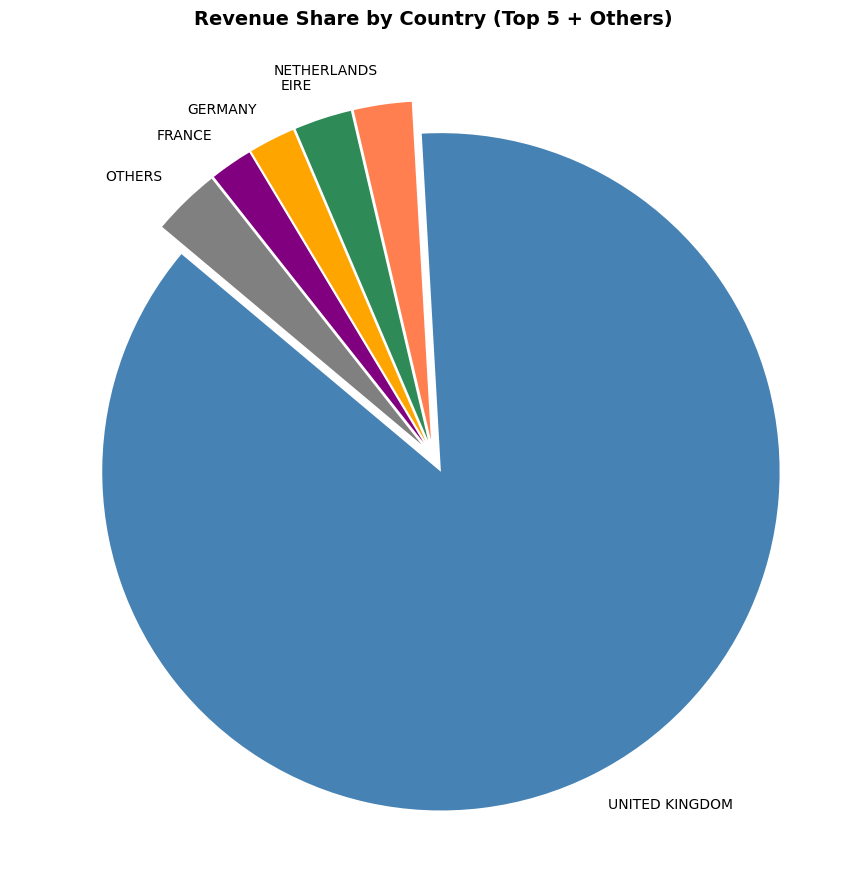

Chart 4 Findings: UK accounts for ~84% of all revenue.
All other countries combined make up only ~16%.


In [36]:
#Chart 4: Pie Chart - Revenue Share by Country
plt.figure(figsize=(9,9))
top5 = top_countries.nlargest(5, 'Total Revenue')
others_value = top_countries.nsmallest(5,'Total Revenue')['Total Revenue'].sum()
labels = list(top5['Country']) + ['OTHERS']
values = list(top5['Total Revenue']) + [others_value]              
explode=[0.05]*len(labels)
colors=['steelblue','coral','seagreen','orange','purple','gray']
plt.pie(values,labels=labels, explode=explode, startangle=140, colors=colors)
plt.title('Revenue Share by Country (Top 5 + Others)',
         fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()
print("Chart 4 Findings: UK accounts for ~84% of all revenue.")
print("All other countries combined make up only ~16%.")
                           

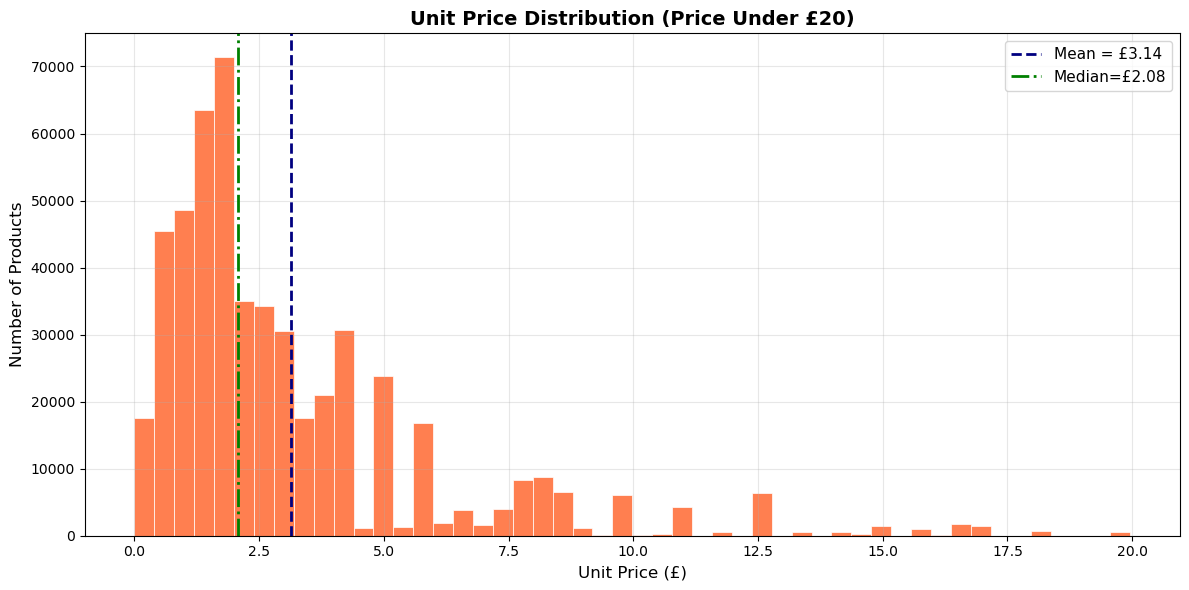

Chart 5 Finding: Most products are priced between £1-£5.
The distribution is right-skewed - a few expensive items
pull the mean above the median.


In [37]:
#Chart 5: Histogram - Unit Price Distribution

plt.figure(figsize=(12,6))
price_filtered = df_clean[df_clean['unitprice'] <20]['unitprice']
plt.hist(price_filtered,bins=50,color='coral',
         edgecolor='white',linewidth=0.5)
plt.axvline(price_filtered.mean(),
            color='navy',
            linestyle='--',
            linewidth=2,
            label=f'Mean = £{price_filtered.mean():.2f}')
plt.axvline(price_filtered.median(),
            color ='green',
            linestyle='-.',
            linewidth=2,
            label=f'Median=£{price_filtered.median():.2f}')
plt.title('Unit Price Distribution (Price Under £20)',
          fontsize=14, fontweight='bold')
plt.xlabel('Unit Price (£)', fontsize=12 )
plt.ylabel('Number of Products', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Chart 5 Finding: Most products are priced between £1-£5.")
print("The distribution is right-skewed - a few expensive items")
print("pull the mean above the median.")

In [38]:
#TASK 5: KEY INSIGHTS
print(""" INSIGHT 1: The UK Dominates Revenue
The United Kingdom generates £9,001,744 in revenue, over 31 times more than the second 
highest country (Netherlands at £285,446).
This means ~84% of all revenue comes from one country.
>> The business is heavily dependent on the UK market.
>> Expanding into Europe could reduce this risk.
[Supported by: Chart 2 and Chart 4]

INSIGHT 2: Revenue Peaks in November (Holiday Season)
Monday revenue nearly TRIPLES from from(£522,546) to November(£1,503,867). This clear Q4 spike shows 
shows customers buy heavily for christmas and holiday gifting.
>> The business should stock up inventory before October.
>> Marketing campaigns should launch in September/October.
[Supported by: Chart 3]

INSIGHT 3: A Few Customers Drive Huge Revenue
The top customer(ID 14646) spent £280,206 alone - likely a wholesale buyer. The top 10 
customers combine represent a significant portion of total revenue.
>> Losing even one top customer would seriously hurt the business.
>> The VIP customers need special relationship management.
[Supported by: EDA 4 - Top Customers Analysis]

INSIGHT 4: Products Are Mostly Low-Cost Gift Items.
The median unit price is only £2.08, with most products priced between £1-£5. This
is a high-volume, low-margin business selling novelty and gift items.
>> Profit depends on selling large quantities.
>> Adding premium product lines could increase revenue per order.
[Suppported by: Chart 5]

INSIGHT 5: Significant Data Quality Issues Need Attention
135,080 rows(25%) had missing CustomerIDs, making it impossible to track one in four 
transactions to a specific customer.
The severely limits customer behaviour analysis.
>> The business should improve its customer registration process.
>> Better data collection would enable more targeted marketing.
[Supported by: Task 2 - Data cleaning]
""")

 INSIGHT 1: The UK Dominates Revenue
The United Kingdom generates £9,001,744 in revenue, over 31 times more than the second 
highest country (Netherlands at £285,446).
This means ~84% of all revenue comes from one country.
>> The business is heavily dependent on the UK market.
>> Expanding into Europe could reduce this risk.
[Supported by: Chart 2 and Chart 4]

INSIGHT 2: Revenue Peaks in November (Holiday Season)
Monday revenue nearly TRIPLES from from(£522,546) to November(£1,503,867). This clear Q4 spike shows 
shows customers buy heavily for christmas and holiday gifting.
>> The business should stock up inventory before October.
>> Marketing campaigns should launch in September/October.
[Supported by: Chart 3]

INSIGHT 3: A Few Customers Drive Huge Revenue
The top customer(ID 14646) spent £280,206 alone - likely a wholesale buyer. The top 10 
customers combine represent a significant portion of total revenue.
>> Losing even one top customer would seriously hurt the business.
>> The

In [41]:
df_clean.to_csv('OnlineRetail_Cleaned.csv', index=False)
print("Cleaned dataset saved as OnlineRetail_Cleaned.csv!")
print(f"Total clean rows saved:{len(df_clean):,}")

Cleaned dataset saved as OnlineRetail_Cleaned.csv!
Total clean rows saved:524,878
